Accessing REN API for Data Analysis

In [1]:
import pandas as pd
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
monthly_energy_balance = "https://servicebus.ren.pt/datahubapi/electricity/ElectricityConsumptionSupplyMonthly?culture=pt-PT&year=2025&month=05"

daily_energy_price = "https://servicebus.ren.pt/datahubapi/electricity/ElectricityMarketPricesDaily?culture=pt-PT&date=2025-01-25"

In [3]:
#Range Analysis 

#-- a) Monthly Energy Balance

start_date = datetime.today()  - timedelta(days = 365 * 4) # 4 years ago
end_date = datetime.today() - timedelta(days = 1) #yesterday
month_list = pd.date_range(start = start_date, end = end_date, freq = 'ME').strftime("%Y-%m").tolist()
print(f"-- a) Monthly Energy Balance from {month_list[0]} to {month_list[-1]}")

#-- b) Daily Energy Price

start_date = datetime.today() - timedelta(days = 364) #one year ago

daily_dates = pd.date_range(start = start_date, end = end_date, freq = 'D').strftime("%Y-%m-%d").tolist()
print(f"-- b) Daily Dates range from {daily_dates[0]} to {daily_dates[-1]}")

-- a) Monthly Energy Balance from 2021-06 to 2025-05
-- b) Daily Dates range from 2024-06-18 to 2025-06-15


In [75]:
#-- Generating the DataFrame for Monthly Energy Balance

all_records = []

for date in month_list:
    url = f"https://servicebus.ren.pt/datahubapi/electricity/ElectricityConsumptionSupplyMonthly?culture=pt-PT&year={date[:4]}&month={date[5:]}"
    response = requests.get(url)
    json_data = response.json()
    for item in json_data:
            record = {
                'Date': date, # Add the date for this row
                'Type': item['type'],
                'Monthly Accumulation': item['monthly_Accumulation']
            }
            all_records.append(record)

df = pd.DataFrame(all_records)

In [76]:
df.pivot_table(index = 'Date', columns = 'Type', values = 'Monthly Accumulation', aggfunc='sum').reset_index()

Type,Date,BIOMASSA,BIOMASSA_COGERACAO,BIOMASSA_OUTROS,CARVAO,CONSUMO,CONSUMO_ARMAZENAMENTO,CONSUMO_BATERIAS,CONSUMO_BOMBAGEM,EOLICA,...,OUTRA_TERMICA,OUTRA_TERMICA_COGERACAO,OUTRA_TERMICA_OUTROS,PRODUCAO_ARMAZENAMENTO,PRODUCAO_BOMBAGEM,PRODUCAO_NAO_RENOVAVEL,PRODUCAO_RENOVAVEL,PRODUCAO_TOTAL,SALDO_IMPORTADOR,SOLAR
0,2021-06,289.0,139.0,150.0,33.0,3842.0,114.0,NaN,114.0,783.0,...,20.0,2.0,18.0,98.0,98.0,1639.0,1896.0,3633.0,324.0,176.0
1,2021-07,290.0,137.0,152.0,70.0,4130.0,78.0,NaN,78.0,933.0,...,15.0,3.0,12.0,61.0,61.0,1417.0,2170.0,3648.0,560.0,212.0
2,2021-08,295.0,138.0,157.0,31.0,3961.0,90.0,NaN,90.0,700.0,...,18.0,2.0,16.0,88.0,88.0,1251.0,1687.0,3027.0,1024.0,212.0
3,2021-09,288.0,126.0,161.0,60.0,4011.0,111.0,NaN,111.0,800.0,...,19.0,2.0,17.0,87.0,87.0,1653.0,1691.0,3431.0,691.0,169.0
4,2021-10,273.0,113.0,160.0,39.0,4026.0,230.0,NaN,230.0,908.0,...,19.0,2.0,17.0,167.0,167.0,1380.0,1826.0,3373.0,883.0,152.0
5,2021-11,288.0,129.0,159.0,73.0,4286.0,161.0,NaN,161.0,1249.0,...,20.0,2.0,17.0,149.0,149.0,1502.0,2328.0,3979.0,468.0,125.0
6,2021-12,301.0,137.0,164.0,0.0,4501.0,220.0,NaN,220.0,1858.0,...,16.0,1.0,15.0,171.0,171.0,1159.0,3019.0,4349.0,372.0,98.0
7,2022-01,299.0,133.0,166.0,NaN,4642.0,204.0,NaN,204.0,1283.0,...,19.0,2.0,17.0,159.0,159.0,1460.0,2455.0,4074.0,772.0,145.0
8,2022-02,274.0,123.0,151.0,NaN,4115.0,258.0,NaN,258.0,890.0,...,18.0,2.0,16.0,202.0,202.0,1263.0,1534.0,2999.0,1375.0,158.0
9,2022-03,301.0,144.0,157.0,NaN,4458.0,200.0,NaN,200.0,1497.0,...,17.0,2.0,15.0,165.0,165.0,1335.0,2559.0,4059.0,600.0,163.0


In [77]:
df.to_parquet('monthly_energy_balance.parquet', index=False)

In [33]:
#-- Generating the DataFrame for Daily Energy Price

all_daily_data_arrays = []

for date in daily_dates:
    url = f"https://servicebus.ren.pt/datahubapi/electricity/ElectricityMarketPricesDaily?culture=pt-PT&date={date}"
    response = requests.get(url)
    json_data = response.json()
    pt_prices = json_data['series'][0]['data']
    es_prices = json_data['series'][1]['data']
    hours = json_data['xAxis']['categories']
    date_column = np.full(len(hours), date)

    daily_data_array = np.column_stack([
        date_column,
        hours,
        pt_prices,
        es_prices
        ])

    all_daily_data_arrays.append(daily_data_array)
    

In [63]:
final_np_array = np.vstack(all_daily_data_arrays)

# Create the DataFrame
df_price = pd.DataFrame(final_np_array, columns=['Date', 'Hour', 'PricePT', 'PriceES'])

df_price.loc[df_price['Hour'].isin(['24', '25']), 'Hour'] = '00' # Adjust hour 24 to 00 for consistency

# Combine Date and Hour into a single datetime column if desired
df_price['DateTime'] = df_price['Date'].astype(str) + ' ' + df_price['Hour'].str.zfill(2) + ':00'
df_price['DateTime'] = pd.to_datetime(df_price['DateTime'])

# Convert price columns to numeric
df_price['PricePT'] = pd.to_numeric(df_price['PricePT'])
df_price['PriceES'] = pd.to_numeric(df_price['PriceES'])

# Drop the separate 'Date' and 'Hour' if 'DateTime' is preferred
df_price = df_price.drop(columns=['Date', 'Hour'])

In [65]:
df_price.set_index('DateTime', inplace = True)

In [66]:
df_price

,PricePT,PriceES
DateTime,,
2024-06-18 01:00:00,51.76,51.76
2024-06-18 02:00:00,37.00,37.00
2024-06-18 03:00:00,51.01,51.01
2024-06-18 04:00:00,52.59,52.59
2024-06-18 05:00:00,53.99,53.99
...,...,...
2025-06-15 20:00:00,13.02,2.40
2025-06-15 21:00:00,53.55,33.96
2025-06-15 22:00:00,76.85,76.85


In [73]:
df_price.to_parquet('daily_energy_price.parquet', index = True)

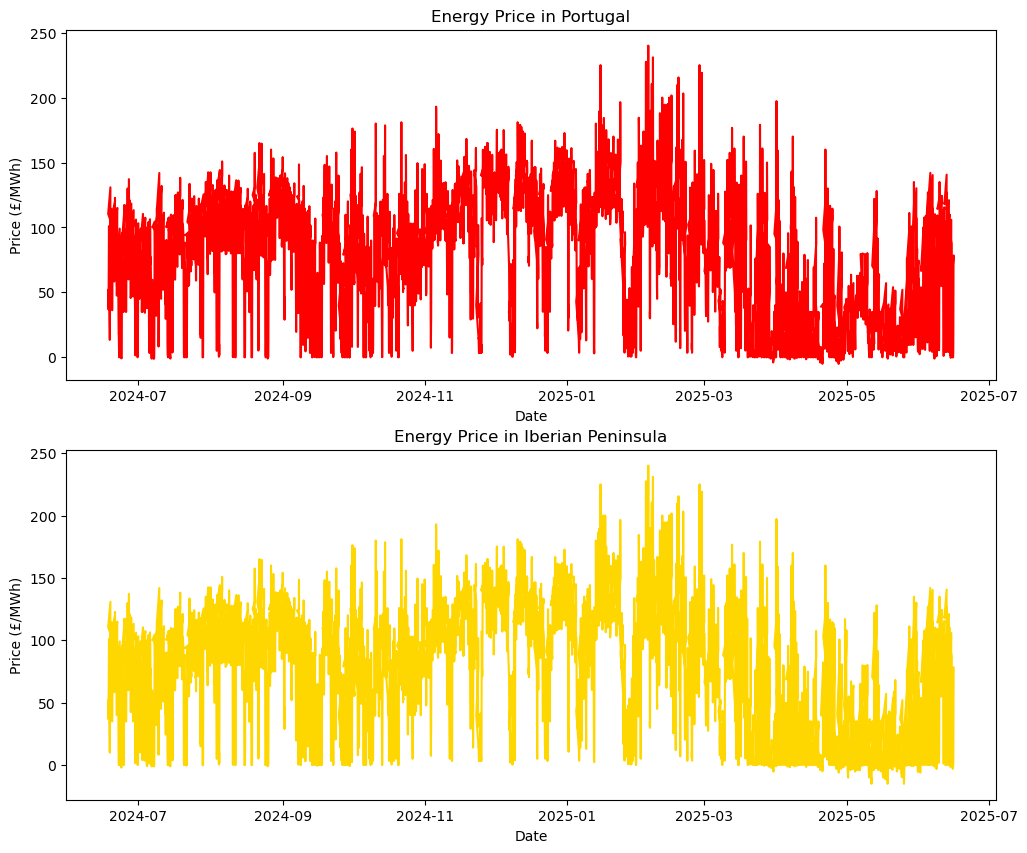

In [68]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(12,10))

#Portugal
ax[0].plot(df_price.index, df_price['PricePT'], label = 'Energy Price in Portugal (£/MWh)', color = 'red')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Price (£/MWh)')
ax[0].set_title('Energy Price in Portugal')

#Spain
ax[1].plot(df_price.index, df_price['PriceES'], label = 'Energy Price in Spain (£/MWh)', color = 'gold')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Price (£/MWh)')
ax[1].set_title('Energy Price in Portugal')


plt.title('Energy Price in Iberian Peninsula')
plt.show()

In [69]:
print(f'Negative Prices in Portugal: {df_price[df_price['PricePT'] < 0].shape[0]}')
print(f'Negative Prices in Spain: {df_price[df_price['PriceES'] < 0].shape[0]}')

Negative Prices in Portugal: 165
Negative Prices in Spain: 518


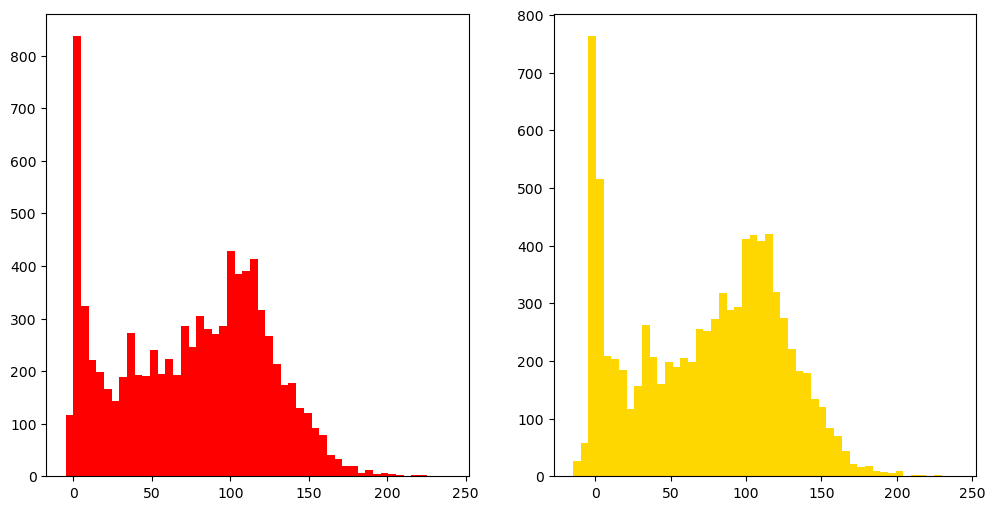

In [72]:
fig, ax = plt.subplots(nrows= 1, ncols = 2, figsize = (12,6))
ax[0].hist(df_price['PricePT'], bins = 50, color = "red", label = 'Portugal')
ax[1].hist(df_price['PriceES'], bins = 50, color = "gold", label = 'Spain')
plt.show()